# Analisis Kualitas Udara (Polutan) di Kawasan Gresik

## 1. Business Understanding

### 1.1 Latar Belakang

Kabupaten Gresik merupakan salah satu kawasan industri terpadat di Provinsi Jawa Timur, dengan konsentrasi pabrik semen, petrokimia, baja, dan pelabuhan yang tinggi. Aktivitas industri ini, ditambah dengan kepadatan lalu lintas kendaraan bermotor, berpotensi menghasilkan emisi gas buang dan partikulat dalam jumlah besar. Kualitas udara yang buruk secara langsung berdampak pada kesehatan masyarakat sekitar, mulai dari gangguan pernapasan ringan hingga penyakit kronis seperti asma, bronkitis, dan penyakit kardiovaskular jika terpapar dalam jangka panjang.

Sayangnya, informasi mengenai kondisi kualitas udara di tingkat kabupaten/kota seringkali tidak tersedia secara real-time atau mudah diakses oleh masyarakat umum. Oleh karena itu, proyek ini mencoba menjawab kebutuhan tersebut dengan memanfaatkan data satelit dan sensor kualitas udara yang tersedia secara terbuka (open data).

### 1.2 Tujuan

Proyek ini bertujuan untuk:
1.  **Mengekstraksi** data historis kualitas udara (level polutan) di wilayah spesifik Kabupaten Gresik selama kurun waktu satu tahun terakhir (31 Agustus 2025 – 31 Agustus 2026) menggunakan API publik.
2.  **Menganalisis** karakteristik statistik dari setiap jenis polutan (CO, NO2, PM10, PM2.5, dan O3), termasuk mendeteksi adanya data yang hilang (*missing values*), nilai negatif, dan outlier.
3.  **Mengetahui tren** pergerakan kualitas udara dari waktu ke waktu (time series) untuk melihat pola musiman, jam-jam dengan polusi tertinggi, atau lonjakan konsentrasi tertentu.
4.  **Menyajikan** hasil analisis dalam bentuk visualisasi yang mudah dipahami oleh berbagai kalangan, baik akademisi, masyarakat umum, maupun pengambil kebijakan.

### 1.3 Rumusan Masalah

Berdasarkan tujuan di atas, terdapat beberapa pertanyaan yang ingin dijawab melalui analisis ini:
*   Bagaimana tren konsentrasi CO, NO2, PM10, PM2.5, dan O3 di Gresik selama satu tahun terakhir?
*   Apakah terdapat pola musiman atau harian (misalnya lebih tinggi di jam sibuk lalu lintas atau musim kemarau)?
*   Apakah ada indikasi anomali data (nilai negatif, data hilang, atau lonjakan ekstrem) yang perlu ditangani sebelum analisis lanjutan?
*   Polutan mana yang paling sering melebihi ambang batas aman menurut standar kesehatan?

### 1.4 Manfaat

*   **Bagi Masyarakat:** Meningkatkan kesadaran akan kondisi kualitas udara di lingkungan sekitar, sehingga masyarakat dapat mengambil langkah preventif (misalnya mengurangi aktivitas luar ruangan atau memakai masker saat konsentrasi polutan tinggi), terutama bagi kelompok rentan seperti anak-anak, lansia, dan penderita gangguan pernapasan.
*   **Bagi Pemerintah:** Mengingat Gresik adalah kawasan perindustrian padat, data ini dapat menjadi landasan atau acuan untuk mengevaluasi efektivitas kebijakan pengendalian emisi dari pabrik dan lalu lintas jalan, serta menjadi dasar untuk perencanaan tata ruang yang lebih ramah lingkungan.
*   **Bagi Akademisi/Peneliti:** Data dan hasil analisis ini dapat menjadi baseline atau titik awal untuk penelitian lanjutan, misalnya pemodelan prediksi kualitas udara (forecasting) atau studi korelasi antara aktivitas industri dan tingkat polusi.

---

## 2. Data Understanding

### 2.1 Sumber Data

Data diperoleh dari **Open-Meteo Air Quality API**, yaitu layanan open data yang menyediakan estimasi konsentrasi polutan udara berbasis model reanalisis atmosfer (mengombinasikan data satelit, model kimia atmosfer CAMS milik Copernicus, dan data stasiun pemantauan darat). Data yang diambil berupa data per jam (*hourly*) selama satu tahun ke belakang, dibatasi pada satu titik koordinat yang mewakili pusat wilayah kajian (Gresik), yang diperoleh dari titik tengah (*centroid*) poligon GeoJSON batas wilayah yang telah ditentukan.

Karena sifatnya berbasis model estimasi (bukan pengukuran langsung dari satu alat sensor fisik di lokasi), nilai yang dihasilkan bisa dianggap sebagai representasi kondisi udara di area tersebut, bukan pengukuran presisi pada satu titik geografis yang sangat spesifik.

### 2.2 Struktur Data

Data yang digunakan merupakan rangkaian *time-series* polutan udara per jam, dengan kolom sebagai berikut:

| Kolom | Tipe Data | Keterangan |
|---|---|---|
| `time` | datetime | Waktu pencatatan (tanggal dan jam) |
| `CO` | float | Konsentrasi Karbon Monoksida (μg/m³) |
| `NO2` | float | Konsentrasi Nitrogen Dioksida (μg/m³) |
| `PM10` | float | Konsentrasi partikel < 10 mikrometer (μg/m³) |
| `PM2.5` | float | Konsentrasi partikel < 2.5 mikrometer (μg/m³) |
| `O3` | float | Konsentrasi Ozon permukaan (μg/m³) |

### 2.3 Deskripsi Fitur (Polutan)

*   **`CO` (Karbon Monoksida):** Gas beracun yang tidak berwarna maupun berbau, dihasilkan dari pembakaran bahan bakar fosil yang tidak sempurna. **Sumber utama:** asap knalpot kendaraan bermotor, pembakaran industri, dan pembakaran biomassa. **Dampak kesehatan:** mengikat hemoglobin dalam darah menggantikan oksigen, sehingga dalam konsentrasi tinggi dapat menyebabkan pusing, mual, hingga keracunan yang berakibat fatal. Baku mutu udara ambien nasional (PP No. 22 Tahun 2021) untuk CO rata-rata 1 jam adalah 10.000 μg/m³.
*   **`NO2` (Nitrogen Dioksida):** Gas berwarna cokelat kemerahan dengan bau tajam menyengat. **Sumber utama:** mesin kendaraan bermotor (terutama diesel), pembangkit listrik tenaga bahan bakar fosil, dan cerobong asap pabrik. **Dampak kesehatan:** mengiritasi saluran pernapasan, memperparah asma, dan dalam jangka panjang menurunkan fungsi paru-paru. Baku mutu rata-rata 1 jam menurut PP No. 22 Tahun 2021 adalah 200 μg/m³.
*   **`PM10` (Particulate Matter ≤10 µm):** Partikel debu/asap berukuran di bawah 10 mikrometer yang dapat masuk ke saluran pernapasan bagian atas. **Sumber:** debu jalan, aktivitas konstruksi, dan asap cerobong pabrik. Baku mutu rata-rata 24 jam adalah 75 μg/m³.
*   **`PM2.5` (Particulate Matter ≤2.5 µm):** Partikel yang jauh lebih halus dan berbahaya karena dapat menembus hingga ke alveolus paru-paru bahkan masuk ke aliran darah. **Sumber:** pembakaran bahan bakar fosil, asap kendaraan diesel, dan pembakaran terbuka (misalnya pembakaran sampah/lahan). Baku mutu rata-rata 24 jam adalah 55 μg/m³, dan termasuk polutan yang paling banyak dikaitkan dengan risiko penyakit jantung dan kanker paru dalam studi epidemiologi.
*   **`O3` (Ozon Permukaan):** Berbeda dengan lapisan ozon stratosfer yang melindungi bumi, ozon permukaan bersifat berbahaya bagi kesehatan. **Terbentuk** dari reaksi fotokimia antara sinar matahari dengan polutan prekursor seperti NO2 dan senyawa organik volatil (VOC), sehingga konsentrasinya cenderung lebih tinggi pada siang hari yang cerah. **Dampak kesehatan:** mengiritasi saluran pernapasan dan memperparah kondisi asma. Baku mutu rata-rata 1 jam adalah 150 μg/m³.

### 2.4 Eksplorasi Data & Pengecekan Anomali

Sebelum data dibersihkan, penting untuk melakukan eksplorasi awal guna mengetahui kondisi data secara umum: tipe data, jumlah baris, rentang nilai, serta indikasi anomali seperti data kosong (*missing values*), nilai negatif, atau outlier ekstrem.

```{note}
Kode di bawah ini hanya **contoh ilustrasi** cara melakukan pengecekan (belum dieksekusi di sini karena `df` belum tersedia — variabel `df` baru terbentuk setelah proses crawling di Bagian 3.B). Kode yang benar-benar dijalankan (executable) ada di **Bagian 3.C**, tepat setelah data hasil crawling dimasukkan ke DataFrame.
```

```python
# Informasi umum struktur data: tipe kolom, jumlah non-null, penggunaan memori
df.info()

# Statistik deskriptif untuk melihat rentang nilai (min, max, mean, std) tiap polutan
# Berguna untuk mendeteksi kejanggalan, misalnya nilai minimum yang negatif
df.describe()

# Cek jumlah missing values (NaN) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isna().sum())

# Cek jumlah nilai negatif per kolom SEBELUM dibersihkan
# Nilai negatif secara logika fisika tidak mungkin terjadi pada konsentrasi gas/partikel
kolom_polutan = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone']
for col in kolom_polutan:
    jumlah_negatif = (df[col] < 0).sum()
    print(f"Jumlah nilai negatif pada {col}: {jumlah_negatif}")

# Deteksi outlier ekstrem menggunakan visualisasi boxplot per kolom polutan
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sebelum Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()
```

Dari eksplorasi di atas, kita bisa memutuskan tiga jenis penanganan anomali:
1.  **Missing Values (NaN):** Data kosong pada jam tertentu, biasanya terjadi saat sensor atau model reanalisis sedang tidak memiliki data (*gap*) untuk lokasi/waktu tersebut.
2.  **Nilai Negatif:** Secara logika, konsentrasi gas atau partikel di udara tidak mungkin bernilai di bawah 0. Jika ditemukan, nilai tersebut merupakan *error* numerik model/sensor dan harus ditangani (diubah menjadi NaN, lalu dapat diisi ulang dengan interpolasi jika diperlukan).
3.  **Lonjakan Ekstrem (Outlier):** Nilai yang mendadak sangat tinggi dibanding nilai di sekitarnya dalam rentang waktu singkat. Outlier tidak selalu berarti error — bisa juga mengindikasikan kejadian nyata seperti kebakaran lahan atau kemacetan ekstrem — sehingga perlu diverifikasi lebih lanjut sebelum dihapus.

---

## 3. Proses Crawling & Pemrosesan Data

Tahapan ini mencakup pengumpulan data dari API berdasarkan batas wilayah spasial, hingga pembersihan dan penyimpanan data ke dalam format CSV.

### A. Setup Batas Wilayah GeoJSON
Kita mulai dengan mendefinisikan batas poligon (*Polygon*) wilayah Gresik yang telah disiapkan, lalu mencari titik tengah (*centroid*) dari area tersebut untuk parameter API.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon

# Definisi koordinat batas wilayah (Gresik) menggunakan GeoJSON
geojson_coords = [
    [112.6568922, -7.1481289],
    [112.6482448, -7.1509091],
    [112.6525927, -7.1672063],
    [112.6657812, -7.1655766],
    [112.6568922, -7.1481289]
]

# Konversi ke bentuk Poligon
area_polygon = Polygon(geojson_coords)

# Mendapatkan koordinat pusat (centroid) untuk API
centroid_lon = area_polygon.centroid.x
centroid_lat = area_polygon.centroid.y
print(f"Titik Pusat Penarikan Data -> Latitude: {centroid_lat:.5f}, Longitude: {centroid_lon:.5f}")

Titik Pusat Penarikan Data -> Latitude: -7.15842, Longitude: 112.65617


Untuk memastikan batas wilayah yang dipakai sudah sesuai (bukan hanya berupa angka koordinat), kita bisa memvisualisasikan poligon tersebut di atas peta interaktif menggunakan `folium`:

In [2]:
import folium

# Membuat peta terpusat di centroid wilayah kajian
peta_wilayah = folium.Map(location=[centroid_lat, centroid_lon], zoom_start=13)

# Menambahkan poligon batas wilayah Gresik ke peta
folium.Polygon(
    locations=[(lat, lon) for lon, lat in geojson_coords],
    color='#e74c3c',
    weight=3,
    fill=True,
    fill_opacity=0.2,
    tooltip='Batas Wilayah Kajian - Gresik'
).add_to(peta_wilayah)

# Menandai titik pusat (centroid) tempat data ditarik
folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup='Titik Pengambilan Data API',
    icon=folium.Icon(color='blue', icon='cloud')
).add_to(peta_wilayah)

peta_wilayah

### B. Mengunduh Data dari API
Menggunakan titik pusat tadi, kita menarik data kualitas udara secara historis selama satu tahun ke belakang.

# Setup Parameter Tanggal dan URL (Sampai 31 Agustus 2026)

In [3]:
start_date = "2025-08-31"
end_date = "2026-08-31"
url = "https://air-quality-api.open-meteo.com/v1/air-quality"

params = {
    "latitude": centroid_lat,
    "longitude": centroid_lon,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone",
    "timezone": "Asia/Jakarta"
}

# Request data

In [4]:
print("Memulai proses crawling...")
response = requests.get(url, params=params)
data = response.json()
print("Data API berhasil ditarik!")

Memulai proses crawling...


Data API berhasil ditarik!


### C. Data Preparation & Penyesuaian Urutan
Setelah data JSON ditarik dari API, kita ubah menjadi DataFrame. Kita juga akan melakukan eksplorasi awal (lihat Bagian 2.4), lalu menghapus anomali nilai negatif, mengisi data yang hilang, dan memastikan urutan data diatur dari yang terlama ke yang terbaru (ascending).

# Memasukkan data ke dalam Pandas DataFrame

In [5]:
df = pd.DataFrame(data['hourly'])
df['time'] = pd.to_datetime(df['time'])

In [6]:
# --- Eksplorasi awal sebelum pembersihan (lihat penjelasan Bagian 2.4) ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              8784 non-null   datetime64[ns]
 1   pm10              8756 non-null   float64       
 2   pm2_5             8756 non-null   float64       
 3   carbon_monoxide   8756 non-null   float64       
 4   nitrogen_dioxide  8756 non-null   float64       
 5   ozone             8756 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 411.9 KB


In [7]:
df.describe()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone
count,8784,8756.000000,8756.000000,8756.000000,8756.000000,8756.000000
mean,2026-03-01 23:30:00,42.773196,41.282652,1055.944929,33.842908,69.873572
min,2025-08-31 00:00:00,6.300000,6.100000,81.000000,2.700000,0.000000
25%,2025-11-30 11:45:00,23.200000,21.700000,497.000000,16.200000,28.000000
50%,2026-03-01 23:30:00,33.800000,32.100000,761.000000,28.500000,52.000000
75%,2026-06-01 11:15:00,52.200000,50.800000,1276.250000,46.100000,107.000000
max,2026-08-31 23:00:00,275.700000,275.700000,8484.000000,195.500000,289.000000
std,NaN,29.920780,29.750471,903.234992,23.481805,54.668438


In [8]:
# Cek jumlah missing values (NaN) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isna().sum())

Jumlah data kosong (missing values) per kolom:
time                 0
pm10                28
pm2_5               28
carbon_monoxide     28
nitrogen_dioxide    28
ozone               28
dtype: int64


In [9]:
# Cek jumlah nilai negatif per kolom SEBELUM dibersihkan
# (nama kolom masih format asli dari API: pm10, pm2_5, carbon_monoxide, nitrogen_dioxide, ozone)
kolom_polutan = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone']
for col in kolom_polutan:
    jumlah_negatif = (df[col] < 0).sum()
    print(f"Jumlah nilai negatif pada {col}: {jumlah_negatif}")

Jumlah nilai negatif pada pm10: 0
Jumlah nilai negatif pada pm2_5: 0
Jumlah nilai negatif pada carbon_monoxide: 0
Jumlah nilai negatif pada nitrogen_dioxide: 0
Jumlah nilai negatif pada ozone: 0


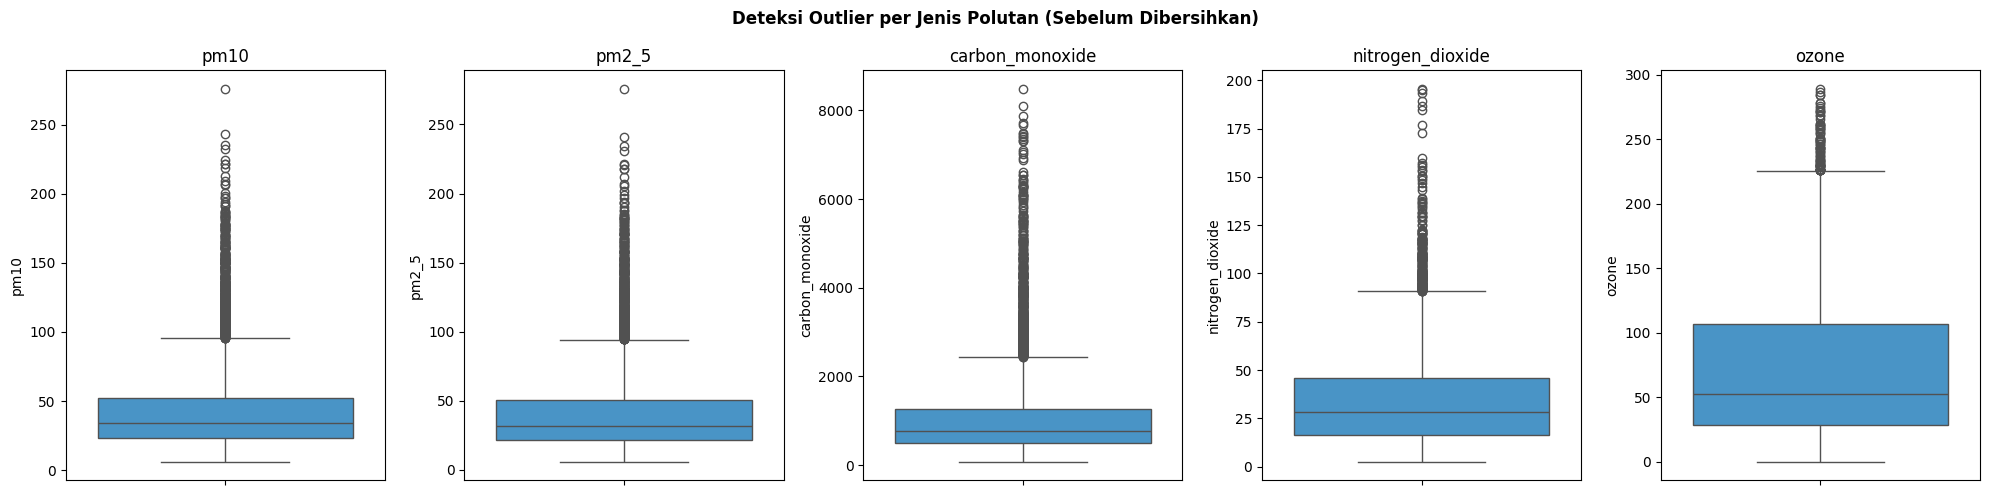

In [10]:
# Deteksi outlier ekstrem menggunakan visualisasi boxplot per kolom polutan
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sebelum Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Mengubah nama kolom agar lebih ringkas

In [11]:
df.rename(columns={
    'carbon_monoxide': 'CO',
    'nitrogen_dioxide': 'NO2',
    'pm10': 'PM10',
    'pm2_5': 'PM2.5',
    'ozone': 'O3'
}, inplace=True)

# Membersihkan anomali: mengubah konsentrasi negatif menjadi Missing Values (NaN)

In [12]:
for col in ['PM10', 'PM2.5', 'CO', 'NO2', 'O3']:
    df.loc[df[col] < 0, col] = None

In [13]:
# Mengisi missing values (NaN) menggunakan interpolasi linear berbasis waktu
# Interpolasi dipilih karena data bersifat time-series dan nilai polutan
# cenderung berubah secara gradual antar-jam, bukan melompat drastis
df = df.set_index('time')
df[['PM10', 'PM2.5', 'CO', 'NO2', 'O3']] = df[['PM10', 'PM2.5', 'CO', 'NO2', 'O3']].interpolate(method='time')
df = df.reset_index()

# Verifikasi ulang tidak ada lagi missing values setelah interpolasi
print("Sisa missing values setelah interpolasi:")
print(df.isna().sum())

Sisa missing values setelah interpolasi:
time     0
PM10     0
PM2.5    0
CO       0
NO2      0
O3       0
dtype: int64


# Mengurutkan waktu secara ASCENDING agar runtun waktu rapi (Data terlama di atas)

In [14]:
df = df.sort_values(by='time', ascending=True).reset_index(drop=True)

# Menyimpan Data menjadi CSV

In [15]:
csv_filename = "polutan_gresik_2025_2026.csv"
df.to_csv(csv_filename, index=False)
print(f"Data disimpan ke dalam bentuk file: {csv_filename}")

Data disimpan ke dalam bentuk file: polutan_gresik_2025_2026.csv


# Menampilkan cuplikan data teratas

In [16]:
df.head()

,time,PM10,PM2.5,CO,NO2,O3
0,2025-08-31 00:00:00,30.7,29.5,860.0,27.3,35.0
1,2025-08-31 01:00:00,39.1,37.6,911.0,29.3,30.0
2,2025-08-31 02:00:00,49.1,47.5,1077.0,31.7,24.0
3,2025-08-31 03:00:00,55.3,53.4,1303.0,34.4,17.0
4,2025-08-31 04:00:00,58.9,56.8,1507.0,36.9,16.0


---

## 4. Visualisasi Grafik (Time Series)
Langkah terakhir adalah memvisualisasikan data runtun waktu yang telah bersih untuk melihat pergerakan tren kualitas udaranya.

### A. Grafik Gas Emisi (CO dan NO2)
Kita me-resample datanya menjadi rata-rata harian agar grafik lebih mudah dibaca dan tidak terlalu menumpuk.

# Resample data per jam menjadi rata-rata harian (D = Daily)

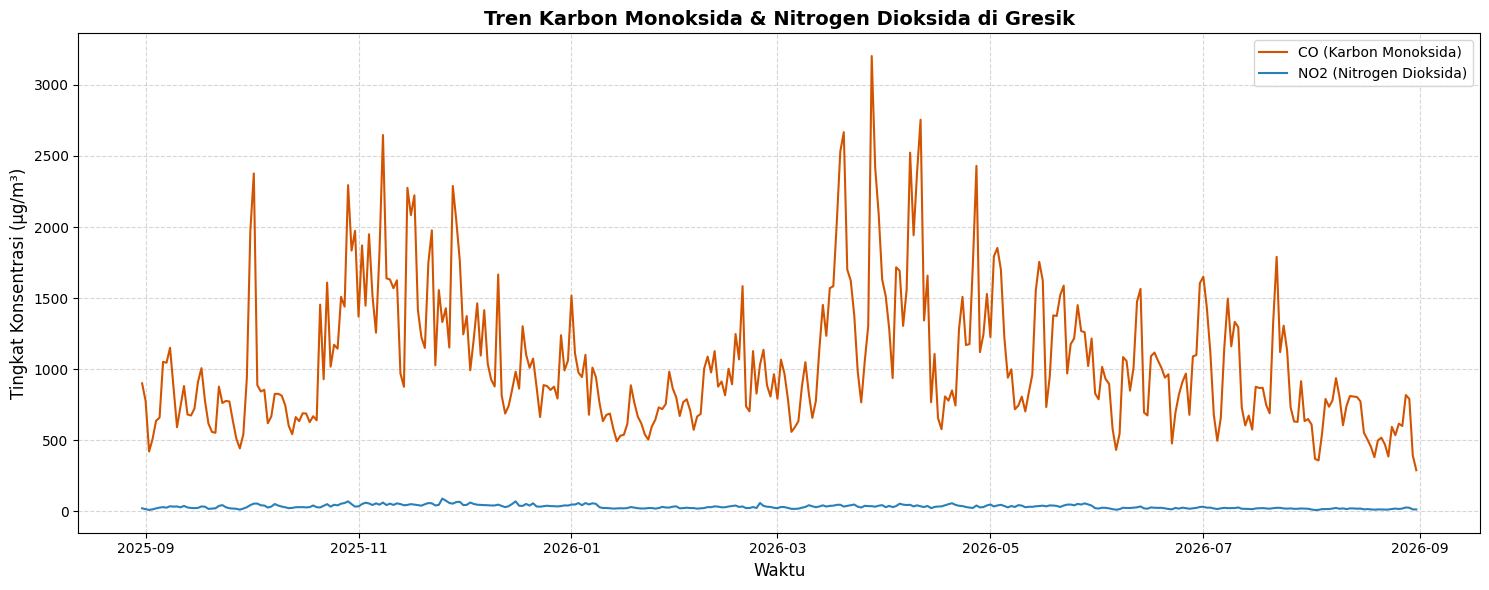

In [17]:
df_daily = df.resample('D', on='time').mean().reset_index()

# Konfigurasi kanvas Matplotlib
plt.figure(figsize=(15, 6))

# Plot Garis untuk Karbon Monoksida dan Nitrogen Dioksida
sns.lineplot(data=df_daily, x='time', y='CO', label='CO (Karbon Monoksida)', color='#d35400')
sns.lineplot(data=df_daily, x='time', y='NO2', label='NO2 (Nitrogen Dioksida)', color='#2980b9')

# Styling Grafik
plt.title('Tren Karbon Monoksida & Nitrogen Dioksida di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### B. Grafik Partikel Berbahaya (PM10 dan PM2.5)
Partikulat sangat penting dipantau di wilayah pabrik dan kendaraan berat karena bentuk fisiknya berupa debu mikro yang berbahaya bagi pernapasan.

# Konfigurasi kanvas Matplotlib

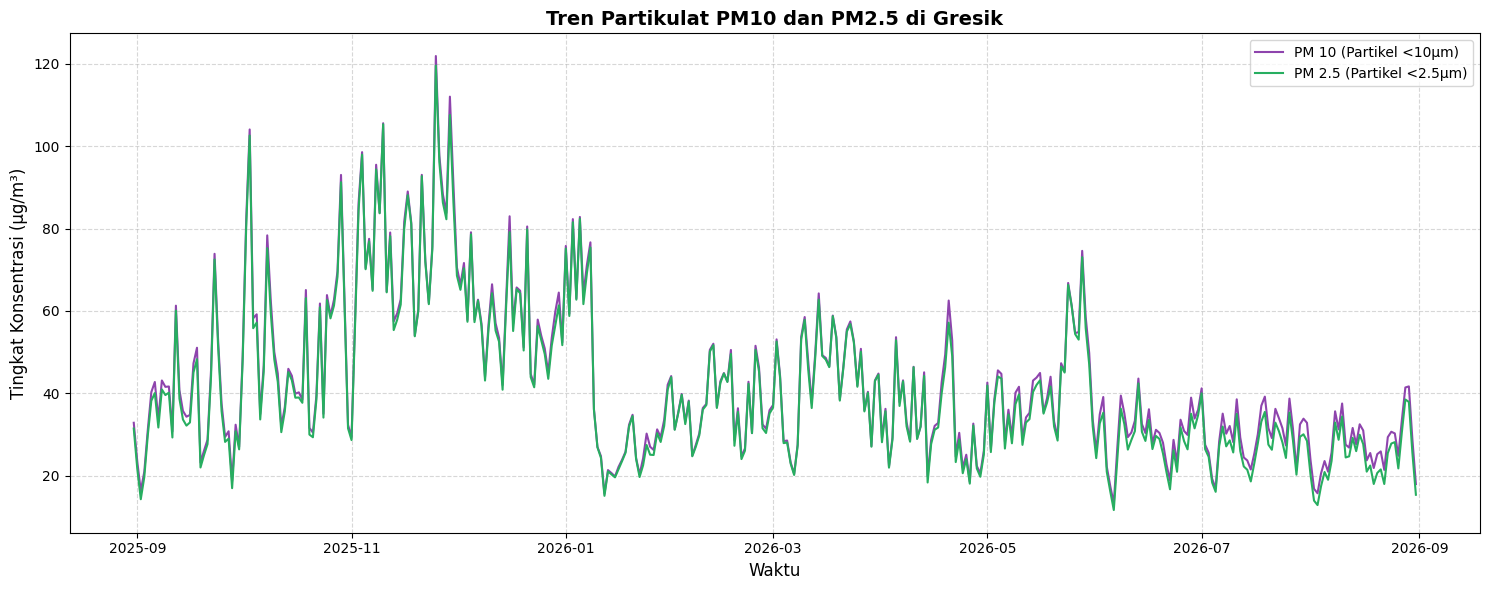

In [18]:
plt.figure(figsize=(15, 6))

# Plot Garis untuk Partikulat
sns.lineplot(data=df_daily, x='time', y='PM10', label='PM 10 (Partikel <10µm)', color='#8e44ad')
sns.lineplot(data=df_daily, x='time', y='PM2.5', label='PM 2.5 (Partikel <2.5µm)', color='#27ae60')

# Styling Grafik
plt.title('Tren Partikulat PM10 dan PM2.5 di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### C. Grafik Ozon Permukaan (O3)
Karena O3 terbentuk dari reaksi fotokimia, polanya cenderung berbeda dengan polutan hasil emisi langsung (CO, NO2), sehingga divisualisasikan secara terpisah.

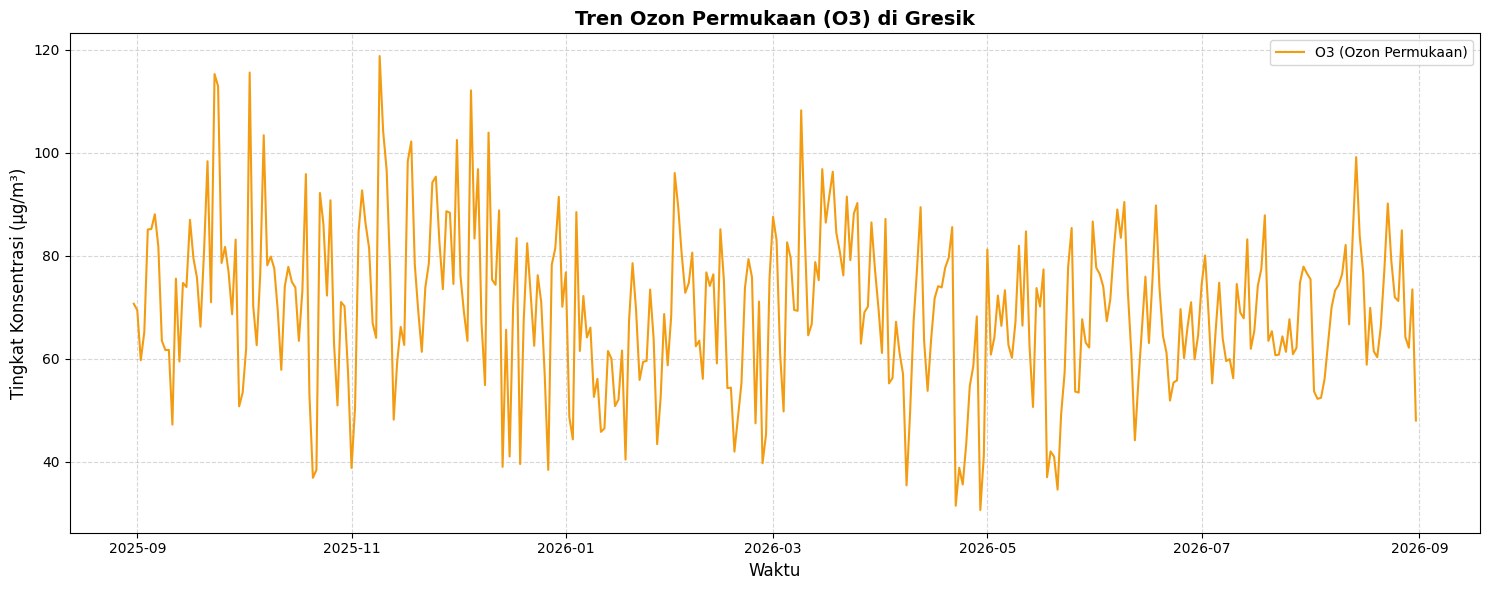

In [19]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=df_daily, x='time', y='O3', label='O3 (Ozon Permukaan)', color='#f39c12')

plt.title('Tren Ozon Permukaan (O3) di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### D. Ringkasan Statistik Akhir

In [20]:
# Ringkasan statistik harian dari seluruh polutan setelah proses pembersihan
df_daily[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].describe()

,CO,NO2,PM10,PM2.5,O3
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1053.503393,33.780931,42.694228,41.200148,69.803848
std,478.154732,13.178619,19.025179,19.149613,15.497494
min,290.000000,10.295833,13.295833,11.700000,30.625000
25%,705.864583,23.357292,29.182292,27.607292,60.791667
50%,928.479167,31.531250,37.091667,35.581250,69.937500
75%,1277.750000,42.361458,53.157292,52.200000,78.708333
max,3202.875000,90.745833,121.845833,119.529167,118.750000


---

## 5. Kesimpulan Sementara

Berdasarkan eksplorasi dan visualisasi di atas, beberapa hal yang dapat disimpulkan (silakan sesuaikan dengan hasil aktual dari data yang ditarik):
*   Tren konsentrasi masing-masing polutan selama satu tahun terakhir dapat diamati melalui grafik time series di Bagian 4.
*   Proses pembersihan data (penanganan nilai negatif dan missing values melalui interpolasi) memastikan data yang dianalisis lebih valid secara logis.
*   Hasil analisis ini dapat menjadi acuan awal bagi masyarakat dan pemerintah setempat dalam memahami pola kualitas udara di Gresik, serta menjadi dasar untuk kajian lanjutan seperti pemodelan prediksi (forecasting) polutan.